<a href="https://colab.research.google.com/github/Moquiuti/Rede-Neural-Deep-Learning-com-PyTorch/blob/main/Otimiza%C3%A7%C3%A3o_e_Taxa_de_Aprendizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Reprodutibilidade
torch.manual_seed(42)

# Carregando dataset de regressão
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Normalizando os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convertendo para tensores
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

print(X.shape)
print(y.shape)

torch.Size([442, 10])
torch.Size([442, 1])


Neste exemplo acima eu usei o dataset de diabetes, igual ao contexto da aula de regressão. A entrada tem várias características e a saída é um valor contínuo.
E logo abaixo eu defini uma rede simples:

In [4]:
class Regressor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

Agora vem a parte que talvez seja a mais importante: que é criar uma função que treina o modelo com uma taxa de aprendizado específica.

In [5]:
def treinar_modelo(learning_rate, epochs=300):
    torch.manual_seed(42)

    model = Regressor(
        input_size=X.shape[1],
        hidden_size=32,
        output_size=1
    )

    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    losses = []

    for epoch in range(epochs):
        # Forward
        pred = model(X)
        loss = criterion(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses

Então eu irei testar várias taxas de aprendizado

In [6]:
taxas = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]

resultados = {}

for lr in taxas:
    resultados[lr] = treinar_modelo(lr)

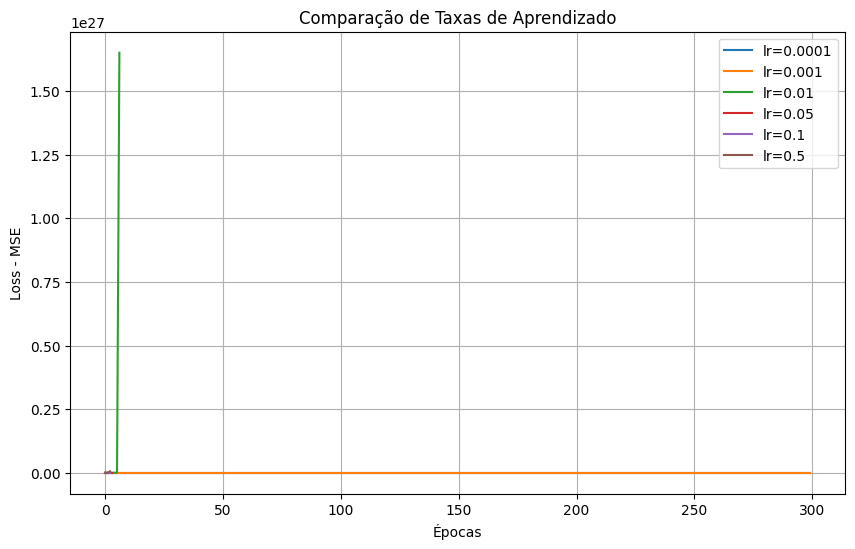

In [7]:
plt.figure(figsize=(10, 6))

for lr, losses in resultados.items():
    plt.plot(losses, label=f"lr={lr}")

plt.xlabel("Épocas")
plt.ylabel("Loss - MSE")
plt.title("Comparação de Taxas de Aprendizado")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
for lr, losses in resultados.items():
    print(f"Learning rate: {lr} | Loss final: {losses[-1]:.4f}")

Learning rate: 0.0001 | Loss final: 2831.5571
Learning rate: 0.001 | Loss final: 2503.2185
Learning rate: 0.01 | Loss final: nan
Learning rate: 0.05 | Loss final: nan
Learning rate: 0.1 | Loss final: nan
Learning rate: 0.5 | Loss final: nan


In [9]:
for lr, losses in resultados.items():
    print(f"\nLearning rate: {lr}")
    print("Primeiras 10 losses:", [round(l, 2) for l in losses[:10]])
    print("Últimas 10 losses:", [round(l, 2) for l in losses[-10:]])


Learning rate: 0.0001
Primeiras 10 losses: [29063.82, 29035.0, 29006.04, 28976.87, 28947.41, 28917.62, 28887.42, 28856.71, 28825.44, 28793.51]
Últimas 10 losses: [2841.85, 2840.63, 2839.44, 2838.26, 2837.11, 2835.97, 2834.85, 2833.72, 2832.62, 2831.56]

Learning rate: 0.001
Primeiras 10 losses: [29063.82, 28773.05, 28436.69, 27970.6, 27237.9, 26015.37, 23978.05, 20795.66, 16556.21, 12314.76]
Últimas 10 losses: [2508.32, 2507.83, 2507.24, 2506.73, 2506.09, 2505.62, 2504.93, 2504.42, 2503.81, 2503.22]

Learning rate: 0.01
Primeiras 10 losses: [29063.82, 25693.15, 9569.17, 31507.05, 742321.44, 154323173376.0, 1.6507372936701327e+27, inf, nan, nan]
Últimas 10 losses: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Learning rate: 0.05
Primeiras 10 losses: [29063.82, 6677.81, 5996926.5, 4.278731460627661e+16, inf, inf, nan, nan, nan, nan]
Últimas 10 losses: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Learning rate: 0.1
Primeiras 10 losses: [29063.82, 136296.58, 13670991003648.0,

Eu mantive o código acima para ficar **evidente** como prova de que taxas altas causam divergência, e à baixo eu escrevi uma versão *mais controlada*, onde comparo melhor várias taxas de aprendizado no gráfico.

In [11]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

a rede e a função de treino mantive iguais, pois a parte mais importante da alteração seria normalizar também o target y. pois no meu primeiro teste eu normalizou o X, mas não o y. Então nessa segunda versão a cima eu fiz desta forma.

In [12]:
taxas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1]

resultados = {}

for lr in taxas:
    resultados[lr] = treinar_modelo(lr)

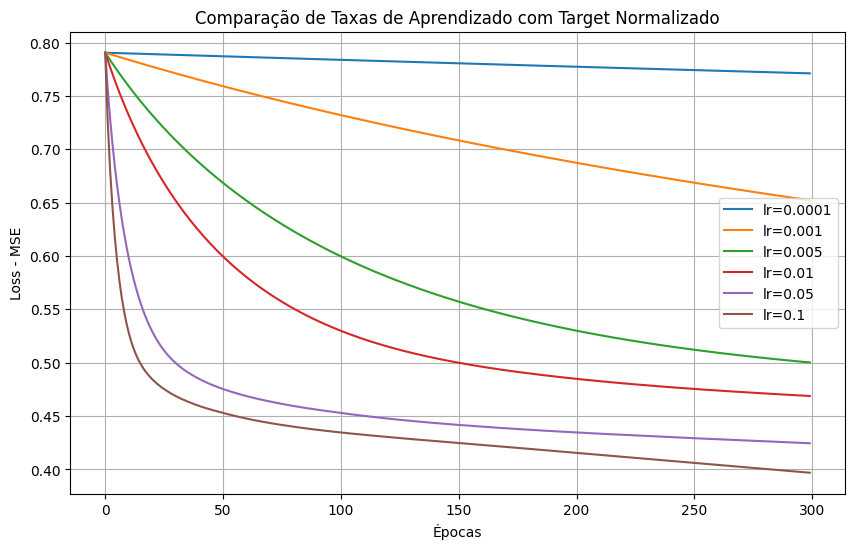

In [13]:
plt.figure(figsize=(10, 6))

for lr, losses in resultados.items():
    plt.plot(losses, label=f"lr={lr}")

plt.xlabel("Épocas")
plt.ylabel("Loss - MSE")
plt.title("Comparação de Taxas de Aprendizado com Target Normalizado")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
for lr, losses in resultados.items():
    print(f"Learning rate: {lr} | Loss final: {losses[-1]:.6f}")

Learning rate: 0.0001 | Loss final: 0.771119
Learning rate: 0.001 | Loss final: 0.652232
Learning rate: 0.005 | Loss final: 0.500235
Learning rate: 0.01 | Loss final: 0.468829
Learning rate: 0.05 | Loss final: 0.424562
Learning rate: 0.1 | Loss final: 0.396933
